# 6. MCH mCG comp

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{mcdir}{ct}_1kb.hdf'`  ·  _other_
- `f'{pmddir}{ct}_10kb_hist.h5ad'`  ·  _PMD/methyl-compartment_
- `f'{outdir}CH_CGcomp_vmax.tsv'`  ·  _table_
- `f'{outdir}{ct}_CH_CGcomp.hdf'`  ·  _other_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed
from statsmodels.tsa.stattools import acf

import pysam
import cooler
import anndata
import scanpy as sc
from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'
mcdir = f'{indir}analysis/mCH_mCG_corr/'
pmddir = f'{indir}analysis/PMD/L1/'
outdir = f'{indir}analysis/mCH_mCG_comp/'


In [3]:
# L1_list = np.sort([xx.split('/')[-1].split('.')[0] for xx in glob(f'{indir}merged_allc/L1/CHN/c*.allc.tsv.gz')])
# # L1_list = L1_list[L1_list!='Hema-B']
# L2_list = np.sort([xx.split('/')[-1].split('.')[0] for xx in glob(f'{indir}merged_allc/L2any/*.CGN-Merge.allc.tsv.gz')])
# print(len(L1_list), len(L2_list))
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()

In [4]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:23]


In [5]:
res = 1000
bed = cooler.util.binnify(chrom_sizes, res)
bed = bed.loc[bed['end']-bed['start']==res].reset_index(drop=True)
bed['name'] = bed['chrom'].astype(str) + '-' + (bed['start']//res).astype(str)
bed['bin10k'] = bed['chrom'].astype(str) + '-' + (bed['start']//10000).astype(str)


In [6]:
context_dict = {'CA': ['CAA', 'CAC', 'CAG', 'CAT', 'CTC'], 
                 'CC': ['CCA', 'CCC', 'CCG', 'CCT'], 
                 'CG': ['CGA', 'CGC', 'CGG', 'CGT'], 
                 'CT': ['CTA', 'CTG', 'CTT']}
# context_dict = {'CH': ['CAA', 'CAC', 'CAG', 'CAT', 'CTC', 'CCA', 'CCC', 'CCG', 'CCT', 'CTA', 'CTG', 'CTT'], 
#                  'CG': ['CGA', 'CGC', 'CGG', 'CGT']}
context_group = {context: k for k,v in context_dict.items() for context in v}

In [14]:
ct = 'c10'
mc = pd.read_hdf(f'{mcdir}{ct}_1kb.hdf', key='mc')
mc = mc.groupby(context_group, axis=1).sum().groupby(bed['bin10k'], axis=0).sum()
cov = pd.read_hdf(f'{mcdir}{ct}_1kb.hdf', key='cov')
cov = cov.groupby(context_group, axis=1).sum().groupby(bed['bin10k'], axis=0).sum()
binfilter = ((cov>10).sum(axis=1)==4)
print(binfilter.sum(), binfilter.shape[0])
ratio = mc / cov
ratio = ratio.loc[binfilter]

In [16]:
adata = anndata.read_h5ad(f'{pmddir}{ct}_10kb_hist.h5ad')
adata.obs.index = adata.obs.index.str.split('-').str[0] + '-' + (adata.obs.index.str.split('-').str[1].astype(int)//10000).astype(str)
selb = adata.obs.index.intersection(ratio.index)
print(selb.shape[0])

In [24]:
adata = adata[selb].copy()
ratio = ratio.loc[selb]
idx = adata.obs['kmeans3'].sort_values().index


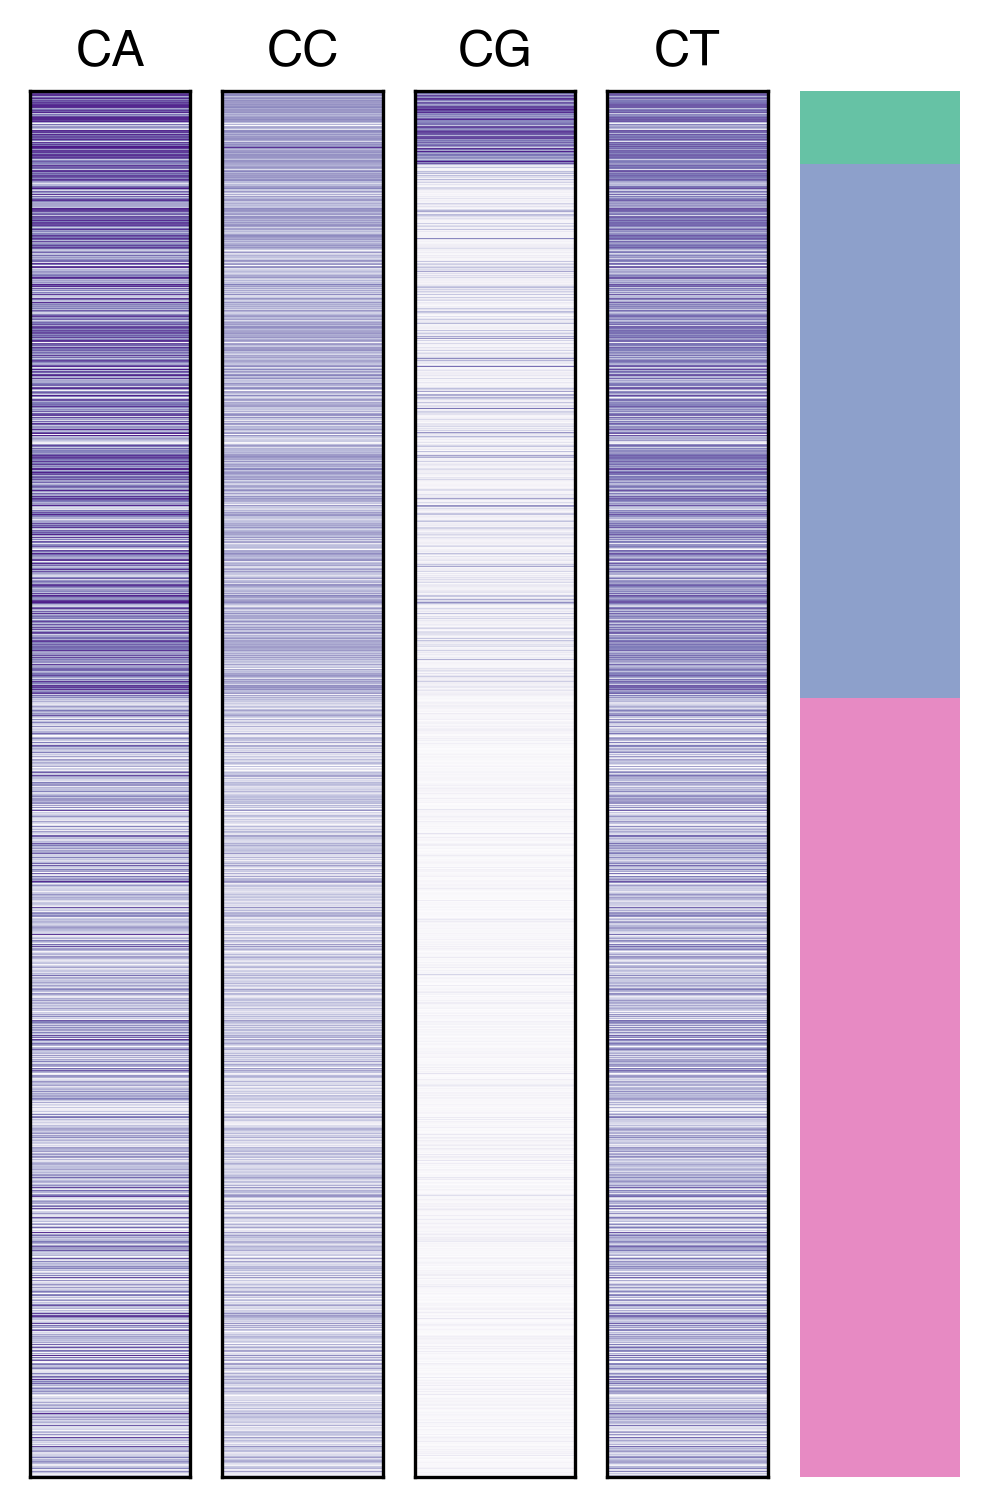

In [36]:
nc = 3
cluster_key = f'kmeans{nc}'
idx = adata.obs[cluster_key].sort_values().index
leg = np.sort(adata.obs[cluster_key].unique())
cluster_color = np.array(sns.color_palette('Set2', 4))[[0,2,3]]
offset = list(adata.obs.loc[idx, cluster_key].value_counts().loc[leg].cumsum())
offset = [0] + offset
# selc = np.random.choice(np.arange(adata.shape[0]), 1000, False)
# idx = adata.obs[cluster_key].iloc[selc].sort_values().index

fig, axes = plt.subplots(1, 5, figsize=(4,6), dpi=300, sharey='all')
for i,context in enumerate(['CA', 'CC', 'CG', 'CT']):
    ax = axes[i]
    tmp = ratio.loc[idx, [context]]
    ax.imshow(tmp, cmap='Purples_r', vmax=np.percentile(tmp, 99), aspect='auto', 
                interpolation='none', rasterized=True)
    ax.set_title(context)
    # ax.set_xticks([-0.5, 49.5, 99.5])
    # ax.set_xticklabels([0, 0.5, 1])
    ax.set_xticks([])
    ax.set_yticks([])

ax = axes[-1]
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, edgecolor='none', facecolor=cluster_color[k])
    ax.add_patch(rect)
    # ax.text(np.mean(offset[i:(i+2)]), -0.2, label, rotation=90, fontsize=10, horizontalalignment='left', verticalalignment='top')


In [7]:
selch = [f'C{x1}{x2}' for x1 in 'ACT' for x2 in 'ACGT']
selch

['CAA',
 'CAC',
 'CAG',
 'CAT',
 'CCA',
 'CCC',
 'CCG',
 'CCT',
 'CTA',
 'CTC',
 'CTG',
 'CTT']

In [19]:
def mc_average_comp(ct):
    mc = pd.read_hdf(f'{mcdir}{ct}_1kb.hdf', key='mc')
    mc = mc[selch].sum(axis=1).groupby(bed['bin10k'], axis=0).sum()
    cov = pd.read_hdf(f'{mcdir}{ct}_1kb.hdf', key='cov')
    cov = cov[selch].sum(axis=1).groupby(bed['bin10k'], axis=0).sum()
    # binfilter = (cov>10)
    # print(binfilter.sum(), binfilter.shape[0])
    ratio = pd.DataFrame(mc / cov, columns=['CH'])
    # ratio = ratio.loc[binfilter]
    ratio['chrom'] = ratio.index.str.split('-').str[0]
    ratio['start'] = ratio.index.str.split('-').str[1].astype(int)
    ratio = ratio.sort_values(['chrom', 'start'])

    adata = anndata.read_h5ad(f'{pmddir}{ct}_10kb_hist.h5ad')
    adata.obs.index = adata.obs.index.str.split('-').str[0] + '-' + (adata.obs.index.str.split('-').str[1].astype(int)//10000).astype(str)
    selb = adata.obs.index.intersection(ratio.index)
    print(selb.shape[0])
    adata = adata[selb].copy()
    # ratio = ratio.loc[selb]

    adata.obs['chrom'] = adata.obs.index.str.split('-').str[0]
    adata.obs['start'] = adata.obs.index.str.split('-').str[1].astype(int)*10000
    adata.obs['end'] = adata.obs['start'] + 10000

    bins = adata.obs[['chrom', 'start', 'end', 'kmeans3']].copy()
    bins['bin_id'] = bins.index
    bins = bins.sort_values(['chrom', 'start'])

    # bins['mCA'] = ratio.loc[bins['bin_id']].values
    # detect breaks: new chrom OR label change OR non-consecutive bin
    bins['prev_end'] = bins.groupby('chrom')['end'].shift()
    bins['new_region'] = (
        (bins['chrom'] != bins['chrom'].shift()) |
        (bins['kmeans3'] != bins['kmeans3'].shift()) |
        (bins['start'] != bins['prev_end'])
    )

    bins['region_id'] = bins['new_region'].cumsum()
    regions = {'chrom': bins.groupby('region_id')['chrom'].first(),
            'start': bins.groupby('region_id')['start'].min(),
            'end': bins.groupby('region_id')['end'].max(),
            'kmeans3': bins.groupby('region_id')['kmeans3'].first()
            }
    regions = pd.DataFrame(regions)
    regions = regions.loc[((regions['end'] - regions['start']) >= 100000)]
    regions = regions.loc[((regions['start']-100000)>= 0) & ((regions['end']+100000)<=chrom_sizes.loc[regions['chrom']].values)]
    print(regions['kmeans3'].value_counts())

    data = {}
    for region_id, chrom, start, end in regions.reset_index()[['region_id','chrom','start','end']].values:
        ratiotmp = ratio.loc[ratio['chrom']==chrom, 'CH'].values
        start, end = start//10000, end//10000
        up = ratiotmp[(start-10):start]
        body = np.array_split(ratiotmp[start:end], 10)
        body = [np.nanmean(x) if len(x) else np.nan for x in body]
        down = ratiotmp[end:(end+10)]
        data[region_id] = np.concatenate([up, body, down])

    data = pd.DataFrame(data).T
    vmax = np.percentile(ratio['CH'][cov>10], 99)
    # data = (data - vmin) / (vmax - vmin)
    data.to_hdf(f'{outdir}{ct}_CH_CGcomp.hdf', key='data')
    regions.to_hdf(f'{outdir}{ct}_CH_CGcomp.hdf', key='regions')
    return vmax


In [20]:
cpu = 12

with ProcessPoolExecutor(cpu) as executor:

    futures = {}
    for ct in L1_meta.index:
        future = executor.submit(
            mc_average_comp,
            ct=ct,
        )
        futures[future] = ct

    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        vmax = future.result()
        result[ct] = vmax
        print(f'Finished {ct}, vmax: {vmax}')


259564
259587
259593259589259589259593259582


259576259594

259595


259594
259585
kmeans3
1    3289
2    2647
0       1
Name: count, dtype: int64
kmeans3
1    2891
2    1777
0       1
Name: count, dtype: int64
kmeans3
2    2777
1    2689
0       3
Name: count, dtype: int64kmeans3
1    3141
2    2756
Name: count, dtype: int64
kmeans3
1    2902
2    2435
0       2
Name: count, dtype: int64

kmeans3
1    3097
2    2598
0       5
Name: count, dtype: int64
kmeans3
2    3131
1    2377
0       7
Name: count, dtype: int64
kmeans3
1    2580
2    2047
0       2
Name: count, dtype: int64
kmeans3
2    2878
1    2660
Name: count, dtype: int64
kmeans3
1    3445
2    2310
0       3
Name: count, dtype: int64
kmeans3
1    3128
2    2858
0       2
Name: count, dtype: int64
kmeans3
2    3776
1    1562
Name: count, dtype: int64
Finished c18, vmax: 0.009387952718574984
Finished c20, vmax: 0.010189149522885617
259577
259589
kmeans3
1    3117
2    1799
0       1
Name: count, dtype: int64
kmeans3
2    3680


In [21]:
result = pd.Series(result)
result.to_csv(f'{outdir}CH_CGcomp_vmax.tsv', sep='\t', header=False)

In [9]:
result = pd.read_csv(f'{outdir}CH_CGcomp_vmax.tsv', sep='\t', header=None, index_col=0).squeeze()

In [10]:
data = {'Partial':{}, 'Hyper':{}}
vmin = 0
for ct in L1_meta.index:
    tmp = pd.read_hdf(f'{outdir}{ct}_CH_CGcomp.hdf', key='data')
    regions = pd.read_hdf(f'{outdir}{ct}_CH_CGcomp.hdf', key='regions')
    vmax = result[ct]
    tmp = (tmp - vmin) / (vmax - vmin)
    tmp = tmp.groupby(regions['kmeans3']).mean()
    data['Partial'][ct] = tmp.loc[1].values
    data['Hyper'][ct] = tmp.loc[2].values

data['Partial'] = pd.DataFrame(data['Partial']).T
data['Hyper'] = pd.DataFrame(data['Hyper']).T


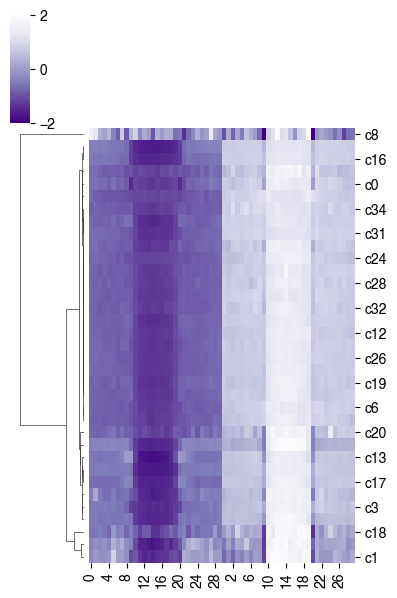

In [47]:
tmp = pd.concat([data['Partial'], data['Hyper']], axis=1)
ave = tmp.mean(axis=1)
std = tmp.std(axis=1)
cg = sns.clustermap(tmp, cmap='Purples_r', metric='cosine', z_score=0, 
                    vmin=-2, vmax=2, figsize=(4,6), col_cluster=False, rasterized=True)
rorder = tmp.index[cg.dendrogram_row.reordered_ind]


In [11]:
leg_order = ['c10', 'c16', 'c14', 'c31', 'c2', 'c5', 
             'c22', 'c9', 'c26', 'c3', 'c13', 'c12', 'c32', 'c27', 'c33', 
             'c30', 'c24', 'c4', 'c0', 'c20', 'c18', 
             'c29', 'c17', 'c28', 'c34', 'c19', 'c11', 'c21', 
             'c25', 'c6', 'c23', 'c15', 'c1', 'c8', 'c7']

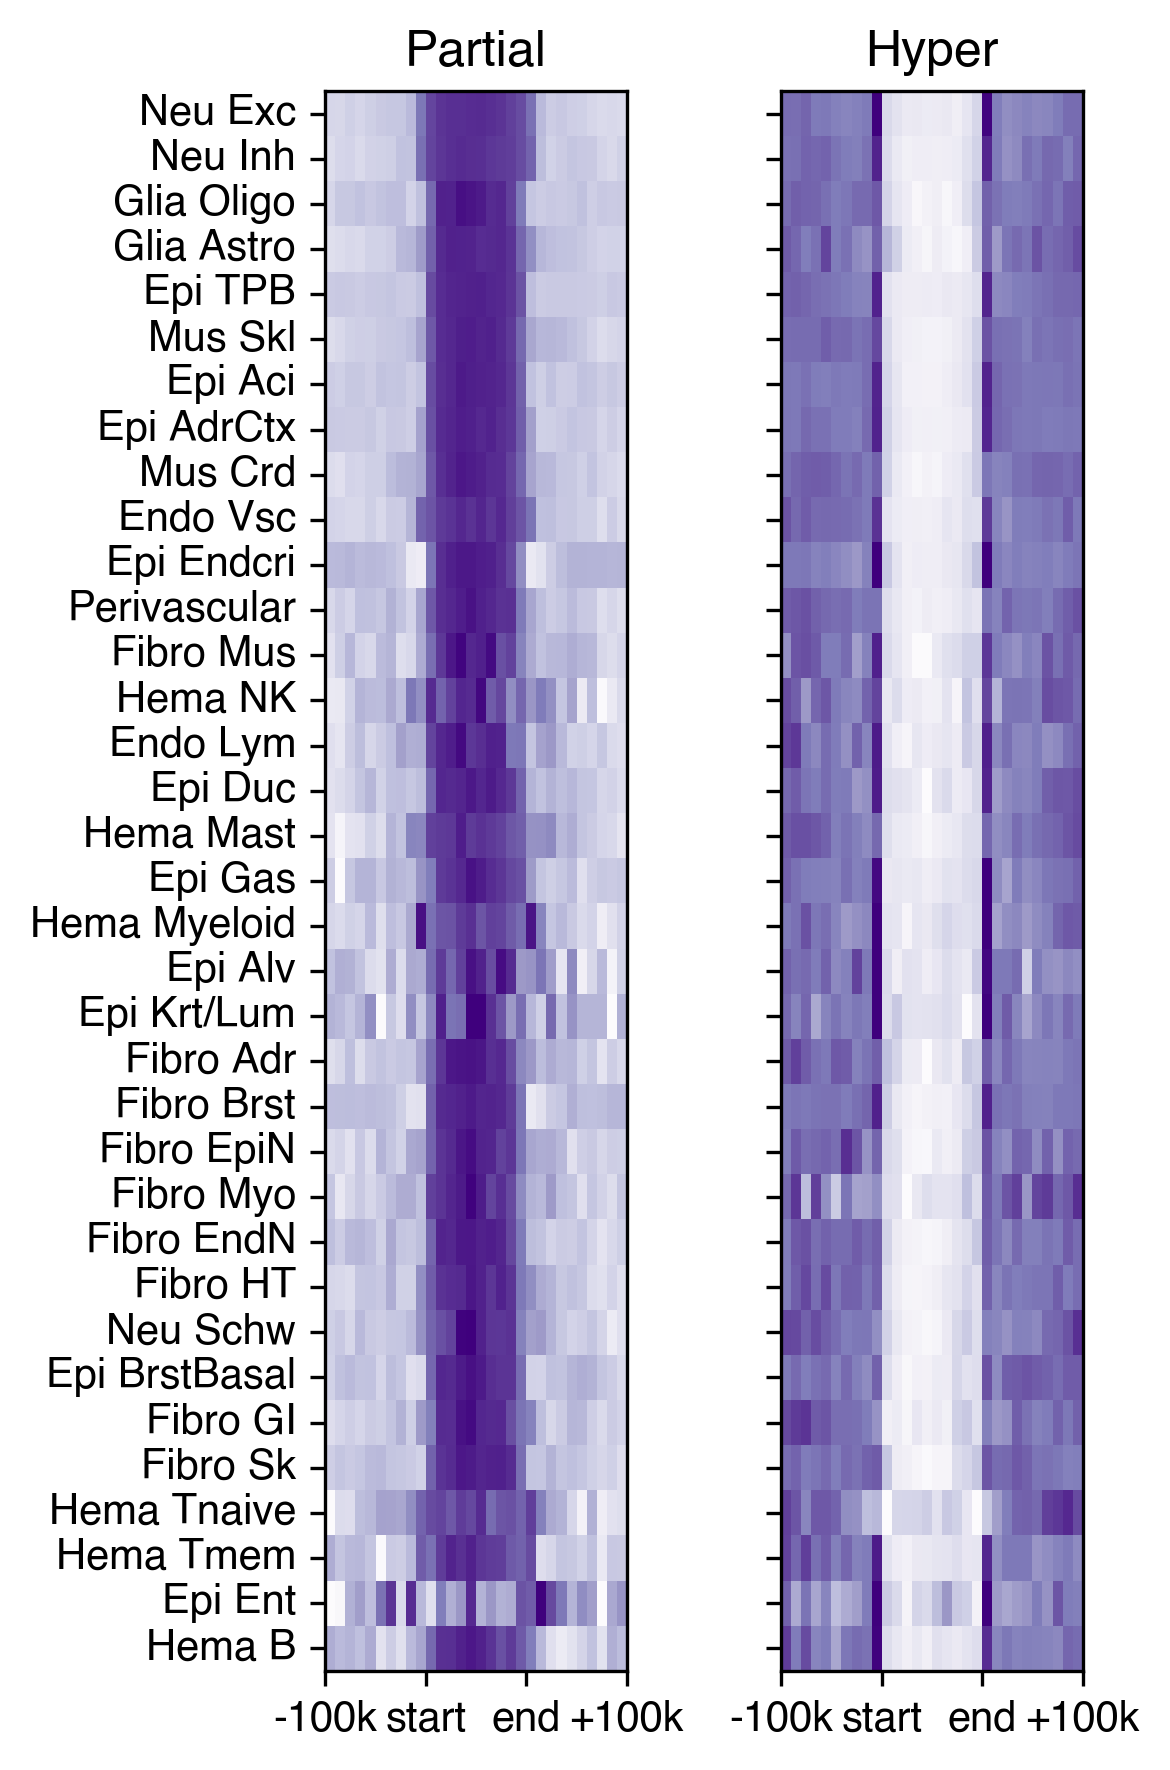

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(4,6), dpi=300, sharey='all')
for i,xx in enumerate(['Partial', 'Hyper']):
    ax = axes[i]
    tmp = zscore(data[xx].loc[leg_order], axis=1)
    sns.heatmap(tmp, cmap='Purples_r', ax=ax, rasterized=True, vmin=-2, vmax=2, cbar=False)
    sns.despine(ax=ax, left=False, bottom=False, right=False, top=False)
    ax.set_title(xx)
    ax.set_xticks([0, 10, 20, 30])
    ax.set_xticklabels(['-100k', 'start', 'end', '+100k'])
    ax.set_yticks(np.arange(tmp.shape[0])+0.5)
    ax.set_yticklabels(tmp.index.map(L1_annot), rotation=0)
    
fig.tight_layout()
fig.savefig(f'{outdir}CGcomp_flankCH.pdf', transparent=True)


In [15]:

def get_window(chrom, start, end):
    return bins[
        (bins['chrom'] == chrom) &
        (bins['start'] >= start) &
        (bins['end'] <= end)
    ].sort_values('start')

rows = []

for rid, grp in bins.groupby('region_id'):
    chrom = grp['chrom'].iloc[0]
    label = grp['kmeans3'].iloc[0]

    region_start = grp['start'].min()
    region_end   = grp['end'].max()

    # upstream: -100kb → start
    up = get_window(chrom, region_start - 100000, region_start)
    up_vals = up['mCA'].values[-10:]
    up_vals = np.pad(up_vals, (10 - len(up_vals), 0), constant_values=np.nan)

    # body: resample to 10 bins
    body_vals = grp['mCA'].values
    body_bins = np.array_split(body_vals, 10)
    body_mean = [np.nanmean(x) if len(x) else np.nan for x in body_bins]

    # downstream: end → +100kb
    down = get_window(chrom, region_end, region_end + 100_000)
    down_vals = down['mCA'].values[:10]
    down_vals = np.pad(down_vals, (0, 10 - len(down_vals)), constant_values=np.nan)

    row = (
        list(up_vals) +
        list(body_mean) +
        list(down_vals)
    )

    rows.append({
        'chrom': chrom,
        'start': region_start,
        'end': region_end,
        'kmeans3': label,
        **{f'bin{i}': row[i] for i in range(30)}
    })

df_regions = pd.DataFrame(rows)


In [21]:
chrom, start, end = chrom, region_start - 100000, region_start

In [22]:
bins[
        (bins['chrom'] == chrom) &
        (bins['start'] >= start) &
        (bins['end'] <= end)]

,chrom,start,end,kmeans3,bin_id,mCA,prev_end,new_region,region_id


In [25]:
start

(137780000, 137880000)

In [31]:
bins.loc[(bins['start'] >= start) & (bins['chrom'] == chrom)]

,chrom,start,end,kmeans3,bin_id,mCA,prev_end,new_region,region_id
chr9-13788,chr9,137880000,137890000,1,chr9-13788,0.011250,137880000.0,True,105257
chr9-13789,chr9,137890000,137900000,1,chr9-13789,0.015725,137890000.0,False,105257
chr9-13790,chr9,137900000,137910000,1,chr9-13790,0.018831,137900000.0,False,105257
chr9-13791,chr9,137910000,137920000,1,chr9-13791,0.015187,137910000.0,False,105257
chr9-13792,chr9,137920000,137930000,1,chr9-13792,0.016394,137920000.0,False,105257
chr9-13793,chr9,137930000,137940000,1,chr9-13793,0.018940,137930000.0,False,105257
chr9-13794,chr9,137940000,137950000,1,chr9-13794,0.014903,137940000.0,False,105257
chr9-13795,chr9,137950000,137960000,1,chr9-13795,0.015809,137950000.0,False,105257
chr9-13796,chr9,137960000,137970000,1,chr9-13796,0.017137,137960000.0,False,105257
chr9-13797,chr9,137970000,137980000,1,chr9-13797,0.014070,137970000.0,False,105257
